Time-Series Forecasting on flight passengers data to forecast the number of passengers for the next 48 months.

In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('AirPassengers.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [4]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [5]:
df.shape

(144, 2)

In [6]:
df['Month']=pd.to_datetime(df['Month'])

In [7]:
df.rename(columns={'#Passengers':'Passengers'},inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [9]:
df.index

RangeIndex(start=0, stop=144, step=1)

In [10]:
df.set_index('Month',inplace=True)

In [11]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


<Axes: xlabel='Month'>

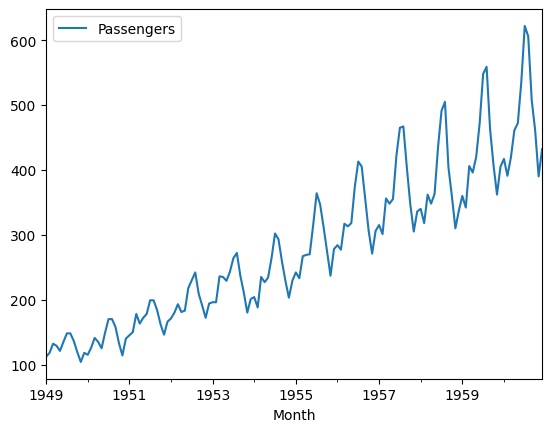

In [12]:
df.plot()

Checking for stationarity

In [13]:
from statsmodels.tsa.stattools import adfuller

In [14]:
res=adfuller(df['Passengers'])

In [15]:
p_val=res[1]

if p_val<0.05:
    print('Accept Null Hypothesis')       # Data is Stationary
else:
    print('Rejectt Null Hypothesis')       # Data is Non-Stationary

Rejectt Null Hypothesis


TS Data tranformations

In [16]:
# mean differencing

rolling_mean=df.rolling(window=12).mean()
rolling_mean_detrened=df-rolling_mean

In [17]:
rolling_mean_detrened.head(15)

,Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,NaN
1949-08-01,NaN
1949-09-01,NaN


<Axes: title={'center': 'Detrended data'}, xlabel='Month'>

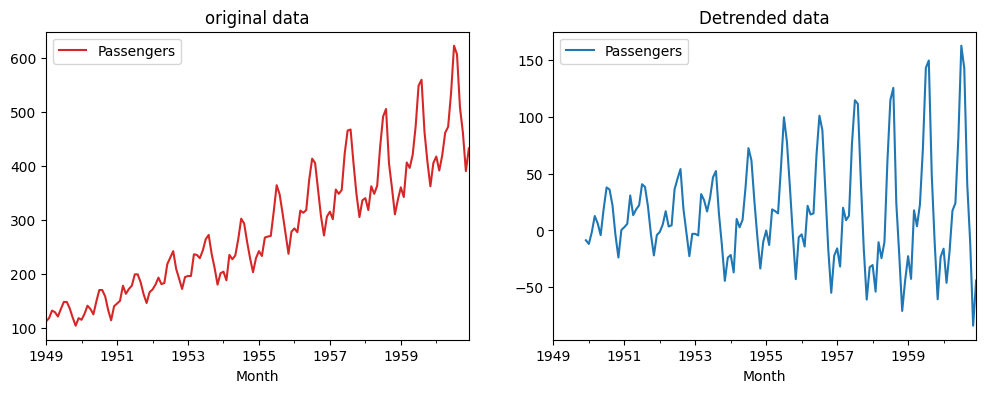

In [18]:
ax1=plt.subplot(1,2,1)
df.plot(figsize=(12,4),color='tab:red',title='original data',ax=ax1)

ax2=plt.subplot(1,2,2)
rolling_mean_detrened.plot(figsize=(12,4),color='tab:blue',title='Detrended data',ax=ax2)

In [19]:
detrened_data=rolling_mean_detrened.dropna()

In [20]:
detrened_data

,Passengers
Month,
1949-12-01,-8.666667
1950-01-01,-11.916667
1950-02-01,-1.583333
1950-03-01,12.666667
1950-04-01,6.166667
...,...
1960-08-01,142.666667
1960-09-01,40.916667
1960-10-01,-10.583333


In [21]:
res1=adfuller(detrened_data['Passengers'])
p_val=res1[1]

if p_val<0.05:
    print('Accept Null Hypothesis')       # Data is Stationary
else:
    print('Rejectt Null Hypothesis')

Accept Null Hypothesis


In [22]:
m=detrened_data.rolling(window=12).mean()
s=detrened_data.rolling(window=12).std()

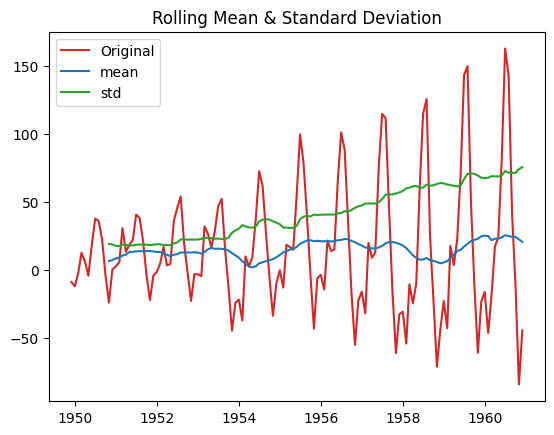

In [23]:
plt.plot(detrened_data,color='tab:red',label='Original')
plt.plot(m,color='tab:blue',label='mean')
plt.plot(s,color='tab:green',label='std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show()

In [24]:
# train-test-split

train=detrened_data[:120]['Passengers']
test=detrened_data[120:]['Passengers']

In [25]:
train.head()

,Passengers
Month,
1949-12-01,-8.666667
1950-01-01,-11.916667
1950-02-01,-1.583333
1950-03-01,12.666667
1950-04-01,6.166667


Building ARIMA model with random parameters

In [26]:
from statsmodels.tsa.arima.model import ARIMA

In [27]:
model=ARIMA(train,order=(1,0,2))
model_fit=model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [28]:
detrened_data['Predict']=model_fit.predict(start=len(train),end=len(train)+len(test)+1)

/tmp/ipykernel_5227/3323344821.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detrened_data['Predict']=model_fit.predict(start=len(train),end=len(train)+len(test)+1)


In [29]:
detrened_data

,Passengers,Predict
Month,,
1949-12-01,-8.666667,NaN
1950-01-01,-11.916667,NaN
1950-02-01,-1.583333,NaN
1950-03-01,12.666667,NaN
1950-04-01,6.166667,NaN
...,...,...
1960-08-01,142.666667,13.223011
1960-09-01,40.916667,13.280638
1960-10-01,-10.583333,13.306771


<Axes: xlabel='Month'>

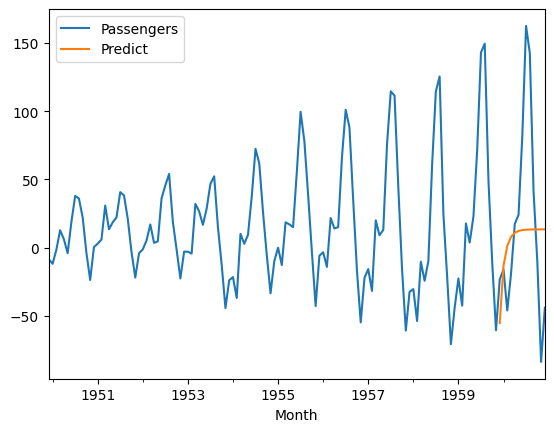

In [30]:
detrened_data[['Passengers','Predict']].plot()

Using auto_arima to know the best suitable model for the given data.

In [42]:
# !pip install numpy==1.26.4

In [32]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 36.3 MB/s eta 0:00:00


In [33]:
from pmdarima import auto_arima

In [34]:
auto=auto_arima(detrened_data['Passengers'])

In [35]:
auto.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  133
Model:               SARIMAX(3, 0, 2)   Log Likelihood                -612.905
Date:                Wed, 15 Apr 2026   AIC                           1239.810
Time:                        11:45:29   BIC                           1260.043
Sample:                    12-01-1949   HQIC                          1248.032
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      6.8579      1.701      4.033      0.000       3.525      10.191
ar.L1          0.8625      0.171      5.045      0.000       0.527       1.198
ar.L2          0.2071      0.236      0.878      0.380      -0.255       0.670
ar.L3         -0.5239      0.142     -3.683      0.000      -0.803      -0.245
ma.L1          0.0684      0.138      0.496      0.620      -0.202       0.338
ma.L2         -0.7564      0.091     -8.293      0.000      -0.935      -0.578
sigma2       577.4776     71.847      8.038      0.000     436.660     718.295
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 8.11
Prob(Q):                              0.89   Prob(JB):                         0.02
Heteroskedasticity (H):               6.21   Skew:                             0.56
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [36]:
# SARIMAX(3,0,2)

In [37]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [38]:
# Initializing and fitting SARIMAX model

final_model=SARIMAX(train,order=(3,0,2),seasonal_order=(3,0,2,12))
final_model_fit=final_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary star

/tmp/ipykernel_5227/3881487405.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detrened_data['Predict']=final_model_fit.predict(start=len(train),end=len(train)+len(test)-1)


<Axes: xlabel='Month'>

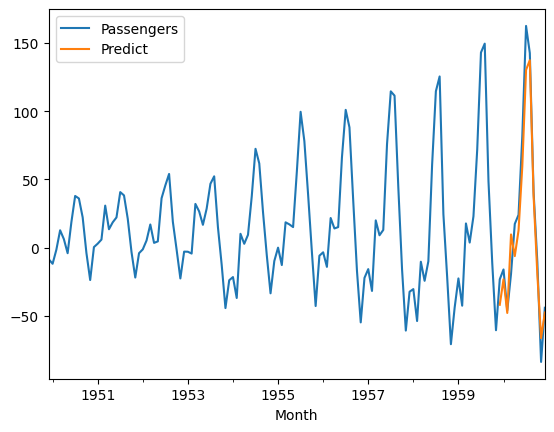

In [39]:
# Predicting test data

detrened_data['Predict']=final_model_fit.predict(start=len(train),end=len(train)+len(test)-1)
detrened_data[['Passengers','Predict']].plot()

Forecasting the next 48 months

In [40]:
forecast=final_model_fit.forecast(steps=48)
forecast

,predicted_mean
1959-12-01,-42.011668
1960-01-01,-23.325939
1960-02-01,-47.993742
1960-03-01,9.597506
1960-04-01,-6.280826
1960-05-01,12.567501
1960-06-01,59.636339
1960-07-01,130.324231
1960-08-01,137.468830
1960-09-01,38.187274


<Axes: xlabel='Month'>

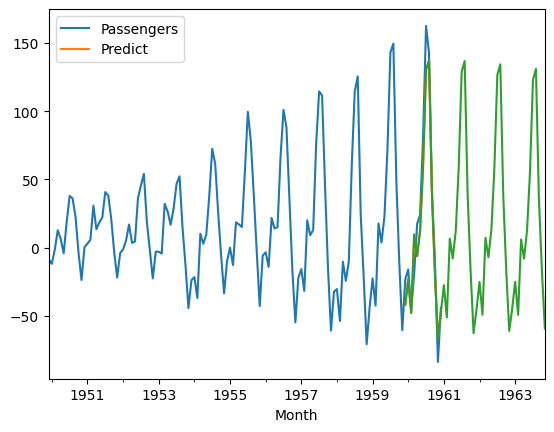

In [41]:
# Final forecasts plot

detrened_data.plot()
forecast.plot()

Hence, SARIMAX(3,0,2) informed by the auto_arima function helped predict the most accurate test data and finally use the same for the next 48 month forecasts after successfully tranforming the time-series data and attaining stationarity.